In [ ]:
### Laboratorio 10: Grafos Dirigidos y Ponderados
# Algoritmo dijkstra

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
grafo = nx.DiGraph()

In [3]:
grafo.add_weighted_edges_from(
    [
        ("Centro","Este",25),
        ("Centro","Norte",10),
        ("Centro","Sur",15),
        ("Norte","Sur",30),
        ("Norte","Este",8),
        ("Norte","Oeste",15),
        ("Sur","Oeste",9),
        ("Este","Aereopuerto",20),
        ("Oeste","Aereopuerto",18),
    ])

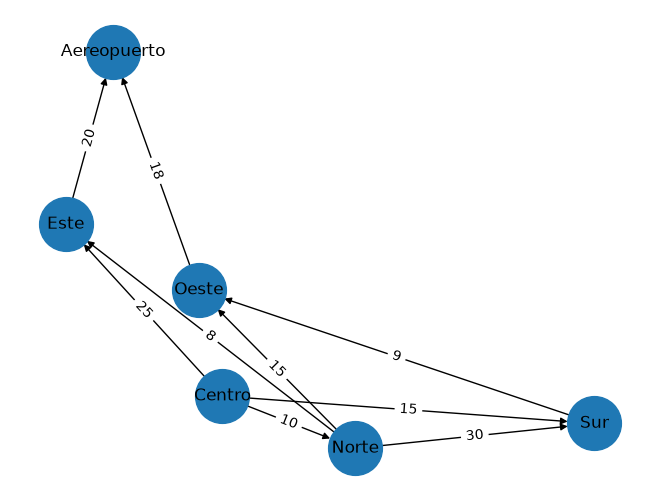

In [4]:
pos = nx.spring_layout(grafo, seed =12)
nx.draw(
    grafo,
    pos,
    with_labels= True,
    node_size=1500,
    arrows=True
)
labels= nx.get_edge_attributes(grafo, "weight")
nx.draw_networkx_edge_labels(
    grafo,
    pos,
    edge_labels=labels
)
plt.show()

In [5]:
#Mostramos las rutas
rutas = list(
    nx.all_simple_paths(
        grafo,
        source="Centro",
        target="Aereopuerto"
    )
)

In [6]:
#Imprimiimos las rutas
for i, ruta in enumerate (rutas, start=1):
    print (f"Ruta {i}:{ruta} ")

Ruta 1:['Centro', 'Este', 'Aereopuerto'] 
Ruta 2:['Centro', 'Norte', 'Sur', 'Oeste', 'Aereopuerto'] 
Ruta 3:['Centro', 'Norte', 'Este', 'Aereopuerto'] 
Ruta 4:['Centro', 'Norte', 'Oeste', 'Aereopuerto'] 
Ruta 5:['Centro', 'Sur', 'Oeste', 'Aereopuerto'] 


In [7]:
#Calculamos el costo
def costo_ruta(grafo, ruta):
    costo=0
    for i in range(len(ruta)-1):
        costo += grafo [ruta[i]][ruta[i+1]]["weight"]
    return costo

In [8]:
#Imprimimos el costo
for i, ruta in enumerate (rutas, start=1):
    costo = costo_ruta (grafo,ruta)
    print (f"Ruta {i}: {ruta}-> {costo}")

Ruta 1: ['Centro', 'Este', 'Aereopuerto']-> 45
Ruta 2: ['Centro', 'Norte', 'Sur', 'Oeste', 'Aereopuerto']-> 67
Ruta 3: ['Centro', 'Norte', 'Este', 'Aereopuerto']-> 38
Ruta 4: ['Centro', 'Norte', 'Oeste', 'Aereopuerto']-> 43
Ruta 5: ['Centro', 'Sur', 'Oeste', 'Aereopuerto']-> 42


In [9]:
#Utilizamos algoritmo para obtener la ruta más corta
ruta_mas_corta=nx.dijkstra_path(grafo, source="Centro" ,target="Aereopuerto" ,weight='weight')
tiempo_total=nx.dijkstra_path_length(grafo, source="Centro", target="Aereopuerto", weight="weight")

In [10]:
#Imprimir
print(f"La mejor ruta más corta es: {ruta_mas_corta}")
print(f"El tiempo total es es: {tiempo_total} minutos")

La mejor ruta más corta es: ['Centro', 'Norte', 'Este', 'Aereopuerto']
El tiempo total es es: 38 minutos
